IMPORTS

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.datasets import mnist
import joblib


EDA

In [126]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

X = X.reshape(-1, 28*28)

X.shape, y.shape

((70000, 784), (70000,))

In [127]:
print("Antal rader:", X.shape[0])
print("Antal features:", X.shape[1])
print("Antal klasser:", len(np.unique(y)))
print("Klasser:", np.unique(y))



Antal rader: 70000
Antal features: 784
Antal klasser: 10
Klasser: [0 1 2 3 4 5 6 7 8 9]


==== VISUALISERING AV EXEMPELBILDER ====
Visar de första 10 siffrorna i datasetet.



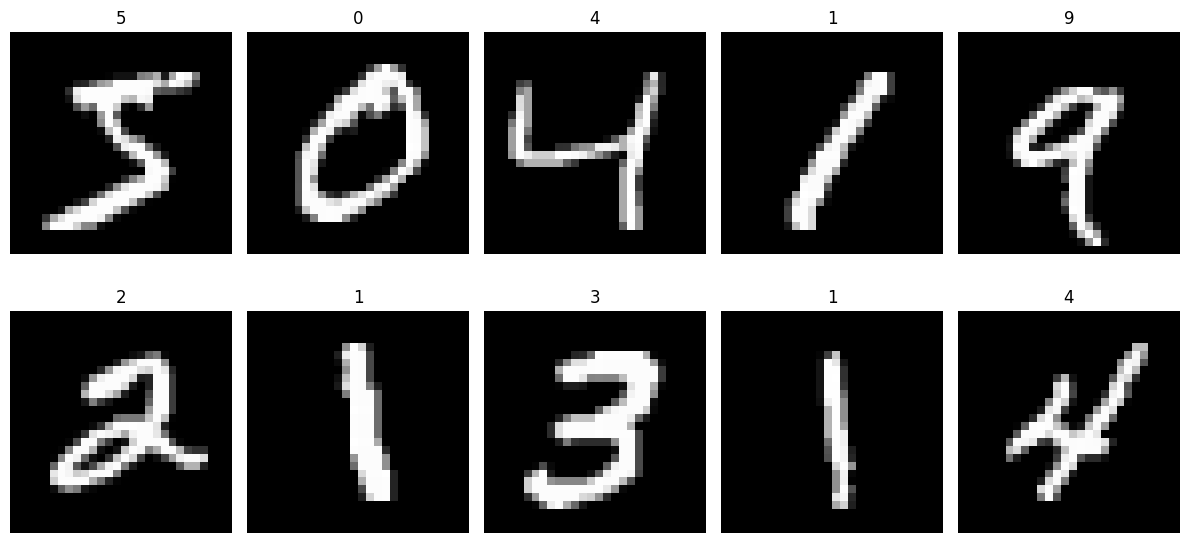

In [128]:
print("==== VISUALISERING AV EXEMPELBILDER ====")
print("Visar de första 10 siffrorna i datasetet.\n")

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap="gray")
    plt.title(f"{y[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()



In [129]:
print("==== MISSING VALUES ====")

df = pd.DataFrame(X)
missing_total = df.isnull().sum().sum()

print(f"Antal saknade värden totalt: {missing_total}")

if missing_total == 0:
    print("Inga saknade värden hittades i datasetet.")
else:
    print("Det finns saknade värden som behöver hanteras.")


==== MISSING VALUES ====
Antal saknade värden totalt: 0
Inga saknade värden hittades i datasetet.


==== KLASSFÖRDELNING ====
Antal observationer per klass:
Siffra 0: 6903 st
Siffra 1: 7877 st
Siffra 2: 6990 st
Siffra 3: 7141 st
Siffra 4: 6824 st
Siffra 5: 6313 st
Siffra 6: 6876 st
Siffra 7: 7293 st
Siffra 8: 6825 st
Siffra 9: 6958 st


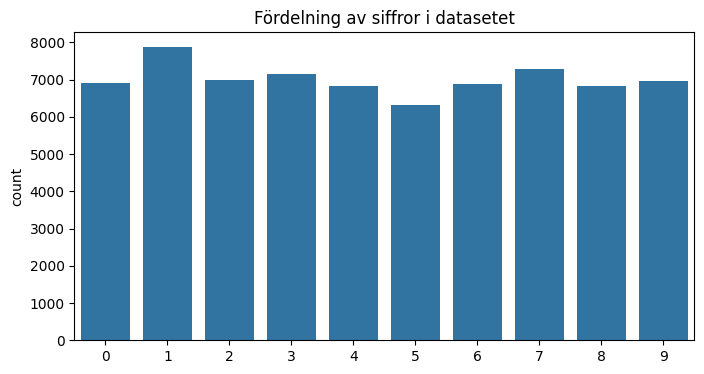

In [130]:
print("==== KLASSFÖRDELNING ====")
print("Antal observationer per klass:")

unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Siffra {u}: {c} st")

plt.figure(figsize=(8, 4))
sns.countplot(x=y)
plt.title("Fördelning av siffror i datasetet")
plt.show()



DATA PREPERATION

In [131]:
print("==== TRAIN / TEST SPLIT ====")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Träningsdata: {X_train.shape[0]} rader")
print(f"Testdata:     {X_test.shape[0]} rader")
print(f"Feature-antal: {X_train.shape[1]}")
print("Stratifiering användes för att behålla klassfördelningen.\n")


==== TRAIN / TEST SPLIT ====
Träningsdata: 56000 rader
Testdata:     14000 rader
Feature-antal: 784
Stratifiering användes för att behålla klassfördelningen.



In [132]:
print("==== SKALNING AV DATA ====")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Skalning genomförd med StandardScaler.")
print(f"Medelvärde (train): {X_train_scaled.mean():.4f}")
print(f"Std (train):        {X_train_scaled.std():.4f}\n")



==== SKALNING AV DATA ====
Skalning genomförd med StandardScaler.
Medelvärde (train): 0.0000
Std (train):        0.9570



DATA MODELING

In [133]:
print("==== LOGISTIC REGRESSION ====")

log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train_scaled, y_train)
log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_acc = accuracy_score(y_test, log_reg_pred)

print("Modellen är tränad och prediktioner är gjorda.\n")

print("==== RANDOM FOREST ====")

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest är tränad och prediktioner är gjorda.\n")

print("==== K-NEAREST NEIGHBORS ====")

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print("KNN är tränad och prediktioner är gjorda.\n")

print("Logistic Regression accuracy:", log_reg_acc)
print("Random Forest accuracy:", rf_acc)
print("KNN accuracy:", knn_acc)


==== LOGISTIC REGRESSION ====
Modellen är tränad och prediktioner är gjorda.

==== RANDOM FOREST ====
Random Forest är tränad och prediktioner är gjorda.

==== K-NEAREST NEIGHBORS ====
KNN är tränad och prediktioner är gjorda.

Logistic Regression accuracy: 0.9163571428571429
Random Forest accuracy: 0.9682142857142857
KNN accuracy: 0.9714285714285714


EVALUATION

In [134]:


best_model = max(
    [(log_reg_acc, "LogisticRegression", log_reg),
     (rf_acc, "RandomForest", rf),
     (knn_acc, "KNN", knn)],
    key=lambda x: x[0]
)

best_model_name = best_model[1]
best_model_obj = best_model[2]

best_model_name



'KNN'

In [135]:
print("==== UTVÄRDERING AV MODELLER ====")

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"Accuracy Logistic Regression: {accuracy_score(y_test, log_reg_pred):.4f}")
print(f"Accuracy Random Forest:       {accuracy_score(y_test, rf_pred):.4f}")
print(f"Accuracy KNN:                 {accuracy_score(y_test, knn_pred):.4f}\n")

print("=== Classification Report: Logistic Regression ===")
print(classification_report(y_test, log_reg_pred))

print("=== Classification Report: Random Forest ===")
print(classification_report(y_test, rf_pred))

print("=== Classification Report: KNN ===")
print(classification_report(y_test, knn_pred))



==== UTVÄRDERING AV MODELLER ====
Accuracy Logistic Regression: 0.9164
Accuracy Random Forest:       0.9682
Accuracy KNN:                 0.9714

=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.95      0.96      0.96      1575
           2       0.92      0.89      0.90      1398
           3       0.89      0.89      0.89      1428
           4       0.93      0.91      0.92      1365
           5       0.87      0.87      0.87      1263
           6       0.94      0.95      0.94      1375
           7       0.92      0.94      0.93      1459
           8       0.89      0.88      0.89      1365
           9       0.90      0.89      0.89      1391

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000

=== Classification Report: Random Forest ===

==== CONFUSION MATRIX ====


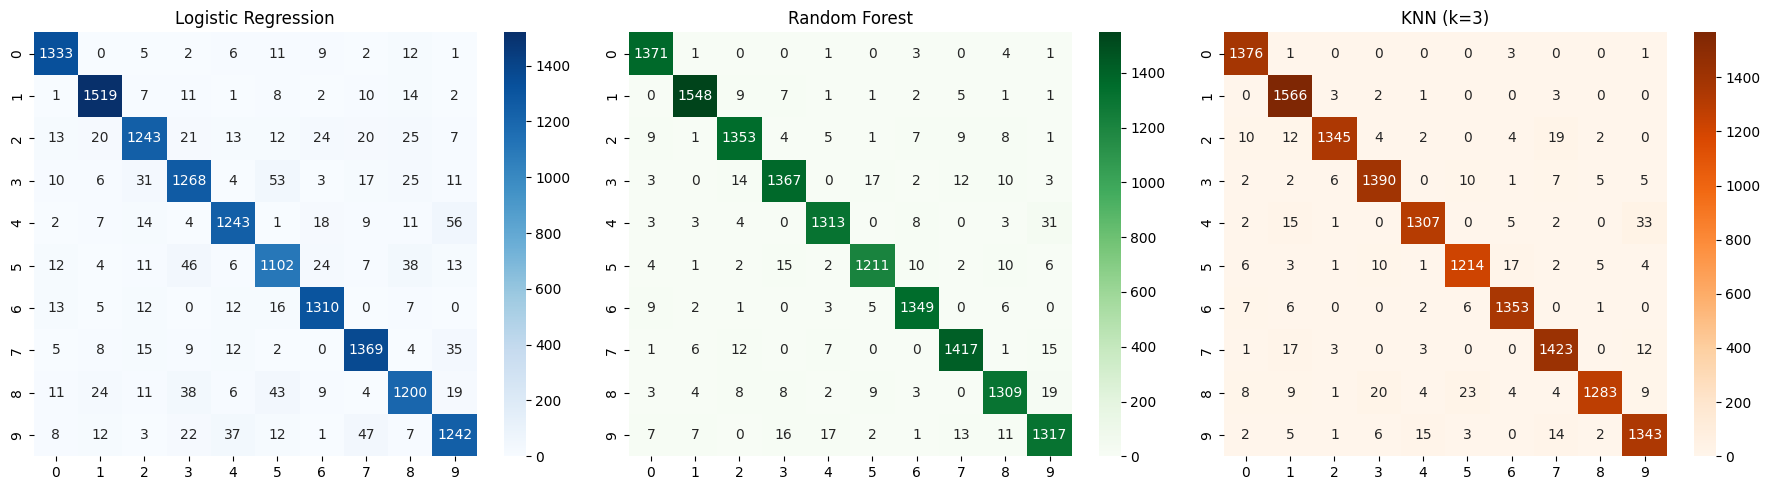

In [136]:
print("==== CONFUSION MATRIX ====")

plt.figure(figsize=(18, 5))   # större bredd för 3 grafer

# Logistic Regression
plt.subplot(1, 3, 1)
sns.heatmap(confusion_matrix(y_test, log_reg_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression")

# Random Forest
plt.subplot(1, 3, 2)
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest")

# KNN
plt.subplot(1, 3, 3)
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt="d", cmap="Oranges")
plt.title("KNN (k=3)")

plt.tight_layout()
plt.show()




In [137]:
print("==== UTVÄRDERING AV MODELLER ====")

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"Accuracy Logistic Regression: {accuracy_score(y_test, log_reg_pred):.4f}")
print(f"Accuracy Random Forest:       {accuracy_score(y_test, rf_pred):.4f}")
print(f"Accuracy KNN:                 {accuracy_score(y_test, knn_pred):.4f}\n")

print("=== Classification Report: Logistic Regression ===")
print(classification_report(y_test, log_reg_pred))

print("=== Classification Report: Random Forest ===")
print(classification_report(y_test, rf_pred))

print("=== Classification Report: KNN ===")
print(classification_report(y_test, knn_pred))

# Välj bästa modellen automatiskt
best_model = max(
    [
        (accuracy_score(y_test, log_reg_pred), "Logistic Regression", log_reg),
        (accuracy_score(y_test, rf_pred), "Random Forest", rf),
        (accuracy_score(y_test, knn_pred), "KNN", knn)
    ],
    key=lambda x: x[0]
)

print(f"\nBästa modellen är: {best_model[1]} med accuracy {best_model[0]:.4f}")

# Spara bästa modellen
joblib.dump(best_model[2], "mnist_model.pkl")


==== UTVÄRDERING AV MODELLER ====
Accuracy Logistic Regression: 0.9164
Accuracy Random Forest:       0.9682
Accuracy KNN:                 0.9714

=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.95      0.96      0.96      1575
           2       0.92      0.89      0.90      1398
           3       0.89      0.89      0.89      1428
           4       0.93      0.91      0.92      1365
           5       0.87      0.87      0.87      1263
           6       0.94      0.95      0.94      1375
           7       0.92      0.94      0.93      1459
           8       0.89      0.88      0.89      1365
           9       0.90      0.89      0.89      1391

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000

=== Classification Report: Random Forest ===

['mnist_model.pkl']

CONCLUSION 

I detta arbete har jag genomfört ett komplett maskininlärningsflöde baserat på MNIST‑datasetet. Arbetet inleddes med en Exploratory Data Analysis (EDA) där jag analyserade datans struktur, kontrollerade efter saknade värden, visualiserade exempelbilder och undersökte klassfördelningen. Datasetet visade sig vara välbalanserat och utan missing values, vilket gjorde det möjligt att gå vidare direkt till modellering.

I Data Preparation‑steget delade jag upp datan i tränings‑ och testmängder samt skalade features med StandardScaler för de modeller som kräver det, framför allt Logistic Regression. Därefter tränade jag tre olika modeller: Logistic Regression, Random Forest och K‑Nearest Neighbors (KNN). Logistic Regression är en linjär modell som gynnas av skalad data, Random Forest är en ensemblemetod som fångar icke‑linjära samband, och KNN är en instansbaserad metod som jämför avstånd mellan datapunkter.

I utvärderingen jämförde jag modellerna med hjälp av accuracy, classification report och confusion matrix. Resultaten visade att alla modeller presterade bra, men KNN uppnådde högst noggrannhet på testdatan och valdes därför som den slutliga modellen. Denna modell sparades och integrerades i en Streamlit‑applikation där användaren kan rita en siffra och få en prediktion i realtid.

Sammanfattningsvis visar arbetet hur man steg för steg kan bygga en komplett maskininlärningspipeline — från datainsamling och EDA till modellering, utvärdering och deployment i en interaktiv applikation. Projektet ger en tydlig och praktisk förståelse för hur klassificeringsproblem kan lösas med maskininlärning och hur olika modeller kan jämföras för att identifiera den som presterar bäst i praktiken.